# História enxuta — incidência × crescimento (Bahia)

**Trabalho:** Inteligência Artificial IV · aprendizado **não supervisionado**

**Pergunta central:** municípios com a mesma incidência, mas trajetórias diferentes, caem em clusters distintos? Essas trajetórias ajudam a ler transições semana a semana?

**Unidade de análise:** município × semana epidemiológica.

**Diferença em relação ao `01_historia_completa.ipynb`:**
- o modelo final não é v5 (6 features);
- o modelo final é **core**: incidência por 100 mil + crescimento semanal;
- a escada serve só para mostrar por que casos absolutos e incidência sozinha são insuficientes.

**Roteiro:**
1. Problema e recorte
2. Dados
3. Baseline v0 (casos)
4. Escada curta: v0 → v1 → core
5. Escolha de K no core
6. Perfis e scatter incidência × crescimento
7. Transições e checagem de utilidade
8. Conclusão

In [38]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

_cwd = Path.cwd().resolve()
if (_cwd / "ml").is_dir():
    ROOT = _cwd
elif (_cwd.parent / "ml").is_dir():
    ROOT = _cwd.parent
else:
    raise RuntimeError("Abra o notebook a partir de ia-iv/ ou ia-iv/notebooks/.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for name in list(sys.modules):
    if name == "ml" or name.startswith("ml."):
        del sys.modules[name]

from ml.cluster import run_kmeans
from ml.columns import Col, Feat, FEATURE_SETS, VERSION_BLOCKS
from ml.config import DEFAULT_K, DEFAULT_MIN_CASOS_ANUAL, DEFAULT_YEARS, REFERENCE_POP_YEAR
from ml.dataset import build_features_panel, load_region_raw
from ml.paths import region_manifest_path
from ml.preprocess import build_region_parquet
from ml.regions import BA
from ml.validate import transition_matrix

REGION = BA.slug
ANO_FOCO = 2024
K_RANGE = list(range(2, 9))
K_FINAL = DEFAULT_K
VERSIONS = ["v0", "v1", "core"]
VERSION_FINAL = "core"
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
ACCENT = "#0072B2"
SCATTER_KW = dict(s=12, alpha=0.35, linewidths=0.2, edgecolors="#333333")

print(f"Projeto: {ROOT}")
print(f"Python: {sys.executable}")
print(f"Região: {BA.name} | Foco: {ANO_FOCO} | K final: {K_FINAL}")
print(f"Modelo final: {VERSION_FINAL} = {list(FEATURE_SETS[VERSION_FINAL])}")
print(f"População/densidade: referência IBGE {REFERENCE_POP_YEAR}")

Projeto: /Users/antonielmagalhaes/d/acad/ia-final/ia-iv
Python: /Users/antonielmagalhaes/d/acad/ia-final/ia-iv/.venv/bin/python
Região: Bahia | Foco: 2024 | K final: 4
Modelo final: core = [<Feat.INCIDENCIA_100K: 'incidencia_100k'>, <Feat.CRESCIMENTO: 'crescimento'>]
População/densidade: referência IBGE 2024


---

## 1. Problema e o que **não** estamos fazendo

Dengue varia no território e no tempo. Olhar só o total de casos responde “quem tem mais volume”, não “quem está piorando”.

| Fazemos | Não fazemos |
|---------|-------------|
| Separar nível (incidência) de trajetória (crescimento) | Prever número exato de casos |
| Interpretar clusters como estágios semanais | Definir oficialmente o que é surto |
| Checar se crescimento antecipa piora | Substituir critérios oficiais de vigilância |

Frase-chave: **dois municípios com incidência parecida podem estar em trajetórias opostas.**

---

## 2. Dados

**Fonte:** SINAN / OpenDataSUS (dengue). **Recorte:** Bahia. **Foco analítico:** 2024.

Em disco ficam `dengue.parquet` e `populacao.parquet`. Features são calculadas em memória.

In [39]:
build_region_parquet(BA, DEFAULT_YEARS)
manifest = json.loads(region_manifest_path(REGION).read_text(encoding="utf-8"))
panel_probe = build_features_panel(REGION, ANO_FOCO, "v0")

print(
    f"{ANO_FOCO}: {manifest['registros_por_ano'].get(str(ANO_FOCO), '?')} notificações | "
    f"{panel_probe[Col.ID_MUNICIP].nunique()} municípios elegíveis (≥{DEFAULT_MIN_CASOS_ANUAL} casos/ano) | "
    f"{len(panel_probe):,} linhas município×semana"
)
display(panel_probe.head(3))

2024: 231942 notificações | 352 municípios elegíveis (≥30 casos/ano) | 18,304 linhas município×semana


,ID_MUNICIP,SEM_NOT,semana_ep,casos
0,290010,202401,1,0
1,290010,202402,2,1
2,290010,202403,3,0


---

## 3. Baseline v0 — casos absolutos

Clusterizar só casos da semana funciona tecnicamente, mas favorece municípios populosos. Silhouette alta aqui é armadilha: em 1D o cluster vira quase ordenação por volume.

In [40]:
def run_version(version: str, k: int = K_FINAL):
    panel = build_features_panel(REGION, ANO_FOCO, version)
    result = run_kmeans(panel, version, k=k)
    return {"version": version, "panel": panel, "result": result}

res_v0 = run_version("v0")
sizes_v0 = pd.Series(res_v0["result"].labels).value_counts().sort_index()
pct_base = 100 * sizes_v0.get(0, 0) / len(res_v0["panel"])

print(f"silhouette v0: {res_v0['result'].metrics['silhouette']:.3f}")
print(f"Cluster 0 concentra {pct_base:.1f}% das linhas município×semana")
display(res_v0["result"].cluster_means.round(2))
display(sizes_v0.rename("linhas"))

silhouette v0: 0.923
Cluster 0 concentra 97.1% das linhas município×semana


,casos
cluster,
0,5.22
1,159.36
2,638.51
3,2539.54


0    17773
1      463
2       57
3       11
Name: linhas, dtype: int64

---

## 4. Escada curta: v0 → v1 → core

| Versão | Features | Papel na narrativa |
|--------|----------|--------------------|
| v0 | casos | baseline trivial |
| v1 | casos + incidência | normaliza por população |
| **core** | **incidência + crescimento** | modelo final: nível × trajetória |

Não usamos média móvel, aceleração nem densidade no fit. O objetivo é um plano 2D interpretável.

,versão,bloco,silhouette,davies_bouldin,n_feat,Δ silhouette
0,v0,baseline: casos,0.9230,0.4512,1,NaN
1,v1,+ incidência por 100 mil,0.8780,0.6064,2,-0.0451
2,core,incidência × crescimento,0.8405,0.7788,2,-0.0374


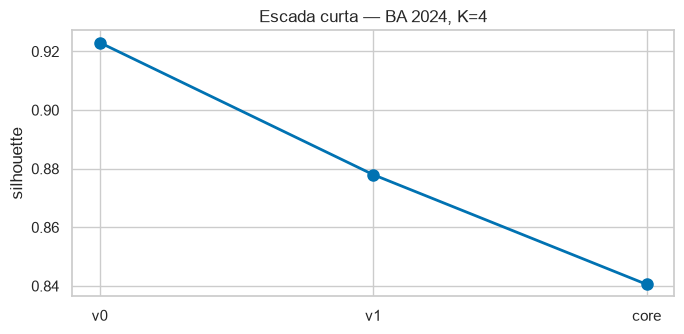

In [41]:
runs_ladder = [run_version(v) for v in VERSIONS]
runs_by = {r["version"]: r for r in runs_ladder}

evo = pd.DataFrame([{
    "versão": r["version"],
    "bloco": VERSION_BLOCKS[r["version"]],
    "silhouette": r["result"].metrics["silhouette"],
    "davies_bouldin": r["result"].metrics["davies_bouldin"],
    "n_feat": len(FEATURE_SETS[r["version"]]),
} for r in runs_ladder])
evo["Δ silhouette"] = evo["silhouette"].diff().round(4)
display(evo.round(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(evo["versão"], evo["silhouette"], "o-", color=ACCENT, lw=2, markersize=8)
ax.set_ylabel("silhouette")
ax.set_title(f"Escada curta — BA {ANO_FOCO}, K={K_FINAL}")
plt.tight_layout()

### 4.1 Por que core e não só incidência?

Em v1, a separação ainda é quase por nível. Em core, o crescimento entra como segunda dimensão: mesma incidência, trajetórias diferentes.

,incidencia_100k,crescimento,casos
cluster,,,
0,15.09,-1.38,5.72
1,287.50,-202.79,83.12
2,334.58,107.77,107.31
3,1099.23,344.68,243.99


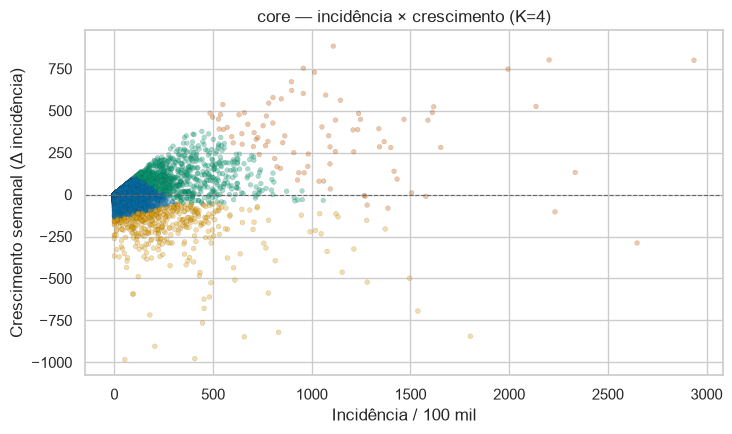

In [42]:
panel_core = runs_by["core"]["panel"]
res_core_ladder = runs_by["core"]["result"]
labeled_core = panel_core.assign(cluster=res_core_ladder.labels)

display(res_core_ladder.cluster_means.round(2))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = labeled_core["cluster"].map({i: PALETTE[i] for i in range(K_FINAL)})
ax.scatter(
    labeled_core[Feat.INCIDENCIA_100K],
    labeled_core[Feat.CRESCIMENTO],
    c=colors,
    **SCATTER_KW,
)
ax.axhline(0, color="#666", lw=0.8, ls="--")
ax.set_xlabel("Incidência / 100 mil")
ax.set_ylabel("Crescimento semanal (Δ incidência)")
ax.set_title(f"core — incidência × crescimento (K={K_FINAL})")
plt.tight_layout()

---

## 5. Escolha de K (modelo final core)

Testamos K de 2 a 8. Preferimos K interpretável: poucos grupos, sem cluster minúsculo demais.

,K,silhouette,davies_bouldin,inertia,menor_cluster
0,2,0.8730,0.7138,23209.1395,524
1,3,0.8575,0.7368,16464.8167,436
2,4,0.8405,0.7788,12890.1394,85
3,5,0.8300,0.8091,10784.8953,45
4,6,0.7843,0.8291,9178.1781,42
5,7,0.7796,0.7602,7874.6878,39
6,8,0.7654,0.7886,6957.1902,25


K escolhido para a narrativa: 4


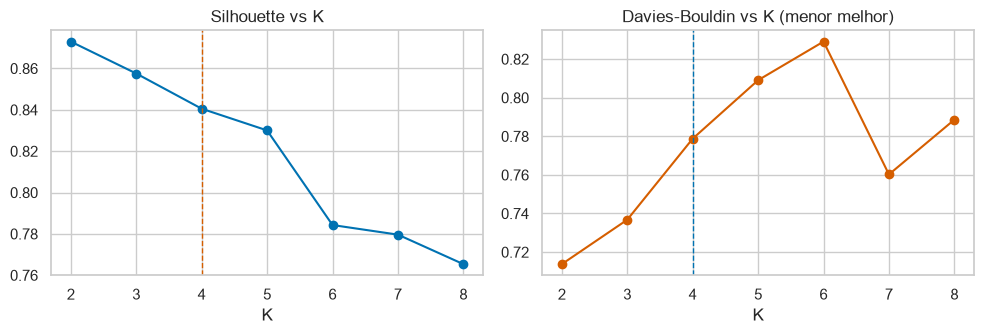

In [43]:
panel_final = build_features_panel(REGION, ANO_FOCO, VERSION_FINAL)
rows = []
for k in K_RANGE:
    r = run_kmeans(panel_final, VERSION_FINAL, k=k)
    sizes = pd.Series(r.labels).value_counts()
    rows.append({
        "K": k,
        "silhouette": r.metrics["silhouette"],
        "davies_bouldin": r.metrics["davies_bouldin"],
        "inertia": r.inertia,
        "menor_cluster": int(sizes.min()),
    })

k_table = pd.DataFrame(rows)
display(k_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(k_table["K"], k_table["silhouette"], "o-", color=ACCENT)
axes[0].axvline(K_FINAL, color="#D55E00", ls="--", lw=1)
axes[0].set_title("Silhouette vs K")
axes[0].set_xlabel("K")
axes[1].plot(k_table["K"], k_table["davies_bouldin"], "o-", color="#D55E00")
axes[1].axvline(K_FINAL, color=ACCENT, ls="--", lw=1)
axes[1].set_title("Davies-Bouldin vs K (menor melhor)")
axes[1].set_xlabel("K")
plt.tight_layout()
print(f"K escolhido para a narrativa: {K_FINAL}")

---

## 6. Perfis dos clusters (core, K=4)

Ordem narrativa dos estados (remapeada após o K-Means):

| ID | Papel |
|----|--------|
| **0** | baixa incidência (estado base) |
| **1** | transição: em queda |
| **2** | transição: em crescimento |
| **3** | alta incidência (estado extremo) |

Nomes são **interpretação pós-cluster**, não rótulos oficiais de vigilância.

Leitura esperada no plano incidência × crescimento:
- baixa incidência estável
- incidência moderada em queda
- incidência moderada/alta em crescimento
- alta incidência (pico)

,incidencia_100k,crescimento,casos,leitura
cluster,,,,
0,15.09,-1.38,5.72,baixa incidência
1,287.50,-202.79,83.12,transição: queda
2,334.58,107.77,107.31,transição: crescimento
3,1099.23,344.68,243.99,alta incidência


cluster
0    17076
1      418
2      725
3       85
Name: linhas, dtype: int64

Participação (%):


cluster
0    93.3
1     2.3
2     4.0
3     0.5
Name: %, dtype: float64

Remapeamento K-Means -> narrativa: {0: 0, 1: 1, 2: 2, 3: 3}


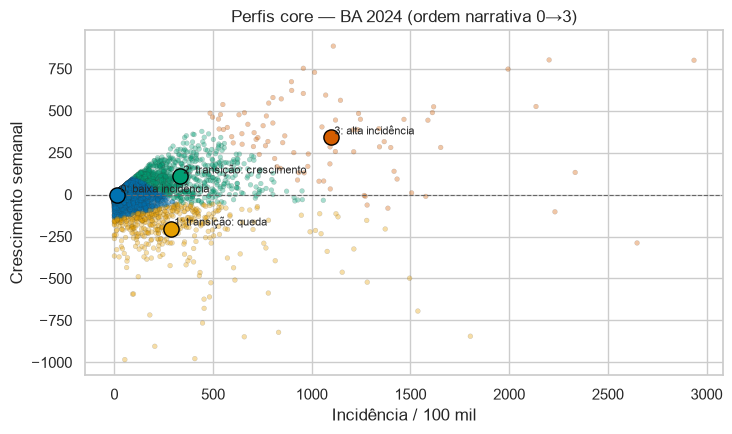

In [44]:
res_raw = run_kmeans(panel_final, VERSION_FINAL, k=K_FINAL)
means_raw = res_raw.cluster_means

# Ordem narrativa (K=4):
# 0 = baixa incidência
# 1 = transição (queda)
# 2 = transição (crescimento)
# 3 = alta incidência  (último estado; com K=4 o ID é 3, não 4)
id_baixa = int(means_raw[Feat.INCIDENCIA_100K].idxmin())
id_alta = int(means_raw[Feat.INCIDENCIA_100K].idxmax())
middle = [i for i in means_raw.index if i not in (id_baixa, id_alta)]
id_queda = int(means_raw.loc[middle, Feat.CRESCIMENTO].idxmin())
id_cresc = int(means_raw.loc[middle, Feat.CRESCIMENTO].idxmax())

# mapa: rótulo antigo do K-Means -> ID narrativo
remap = {id_baixa: 0, id_queda: 1, id_cresc: 2, id_alta: 3}
labels_ordered = np.array([remap[int(x)] for x in res_raw.labels])

NOMES = {
    0: "baixa incidência",
    1: "transição: queda",
    2: "transição: crescimento",
    3: "alta incidência",
}

labeled = panel_final.assign(cluster=labels_ordered)
means = labeled.groupby("cluster")[[Feat.INCIDENCIA_100K, Feat.CRESCIMENTO, Feat.CASOS]].mean().round(3)
means = means.reindex(range(K_FINAL))
sizes = labeled["cluster"].value_counts().reindex(range(K_FINAL)).fillna(0).astype(int)

# resultado final usado nas seções seguintes (transições / FSM / utilidade)
res_final = res_raw
res_final.labels = labels_ordered
res_final.cluster_means = means

perfis = means.round(2).copy()
perfis["leitura"] = perfis.index.map(NOMES)
display(perfis)
display(sizes.rename("linhas"))
print("Participação (%):")
display((100 * sizes / len(labeled)).round(1).rename("%"))
print("Remapeamento K-Means -> narrativa:", remap)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = labeled["cluster"].map({i: PALETTE[i] for i in range(K_FINAL)})
ax.scatter(labeled[Feat.INCIDENCIA_100K], labeled[Feat.CRESCIMENTO], c=colors, **SCATTER_KW)
ax.axhline(0, color="#666", lw=0.8, ls="--")
for i, row in means.iterrows():
    ax.scatter(row[Feat.INCIDENCIA_100K], row[Feat.CRESCIMENTO], s=120, c=PALETTE[i], edgecolors="black", zorder=3)
    ax.text(row[Feat.INCIDENCIA_100K], row[Feat.CRESCIMENTO], f" {i}: {NOMES[i]}", fontsize=8, va="bottom")
ax.set_xlabel("Incidência / 100 mil")
ax.set_ylabel("Crescimento semanal")
ax.set_title(f"Perfis core — BA {ANO_FOCO} (ordem narrativa 0→3)")
plt.tight_layout()


---

## 7. Transições semana t→t+1

Como cada município muda de perfil entre semanas consecutivas. Análise **posterior** ao clustering.

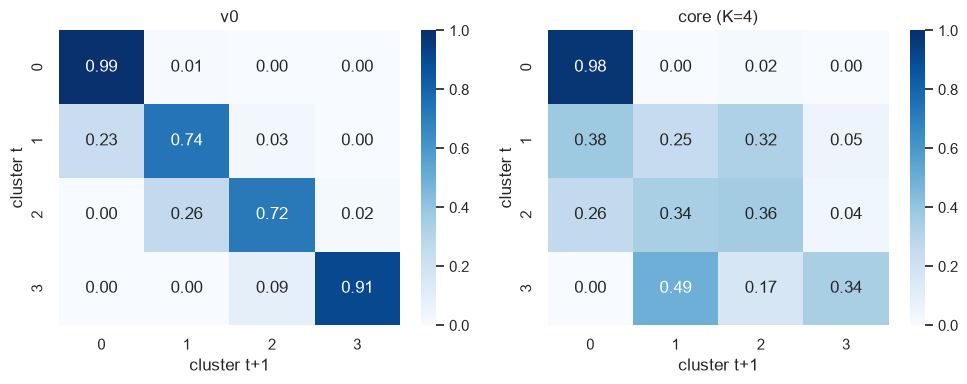

In [45]:
trans_v0 = transition_matrix(runs_by["v0"]["panel"], runs_by["v0"]["result"].labels)
trans_core = transition_matrix(panel_final, res_final.labels)

# mesma ordem narrativa dos IDs (0 baixa … 3 alta)
STATE_ORDER = list(range(K_FINAL))
trans_v0_ord = trans_v0.reindex(index=STATE_ORDER, columns=STATE_ORDER)
trans_core_ord = trans_core.reindex(index=STATE_ORDER, columns=STATE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, trans, title in [
    (axes[0], trans_v0_ord, "v0"),
    (axes[1], trans_core_ord, f"core (K={K_FINAL})"),
]:
    sns.heatmap(trans, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
    ax.set_xlabel("cluster t+1")
    ax.set_ylabel("cluster t")
    ax.set_title(title)
plt.tight_layout()


### Diagrama de estados (FSM) — core, K=4

Desenhado com **Graphviz** (`circo`), não matplotlib.

- só o modelo **core**
- **nenhuma transição cortada** (inclui 0→1 e 0→2)
- self-loops no lado externo de cada nó
- ida e volta em arestas separadas


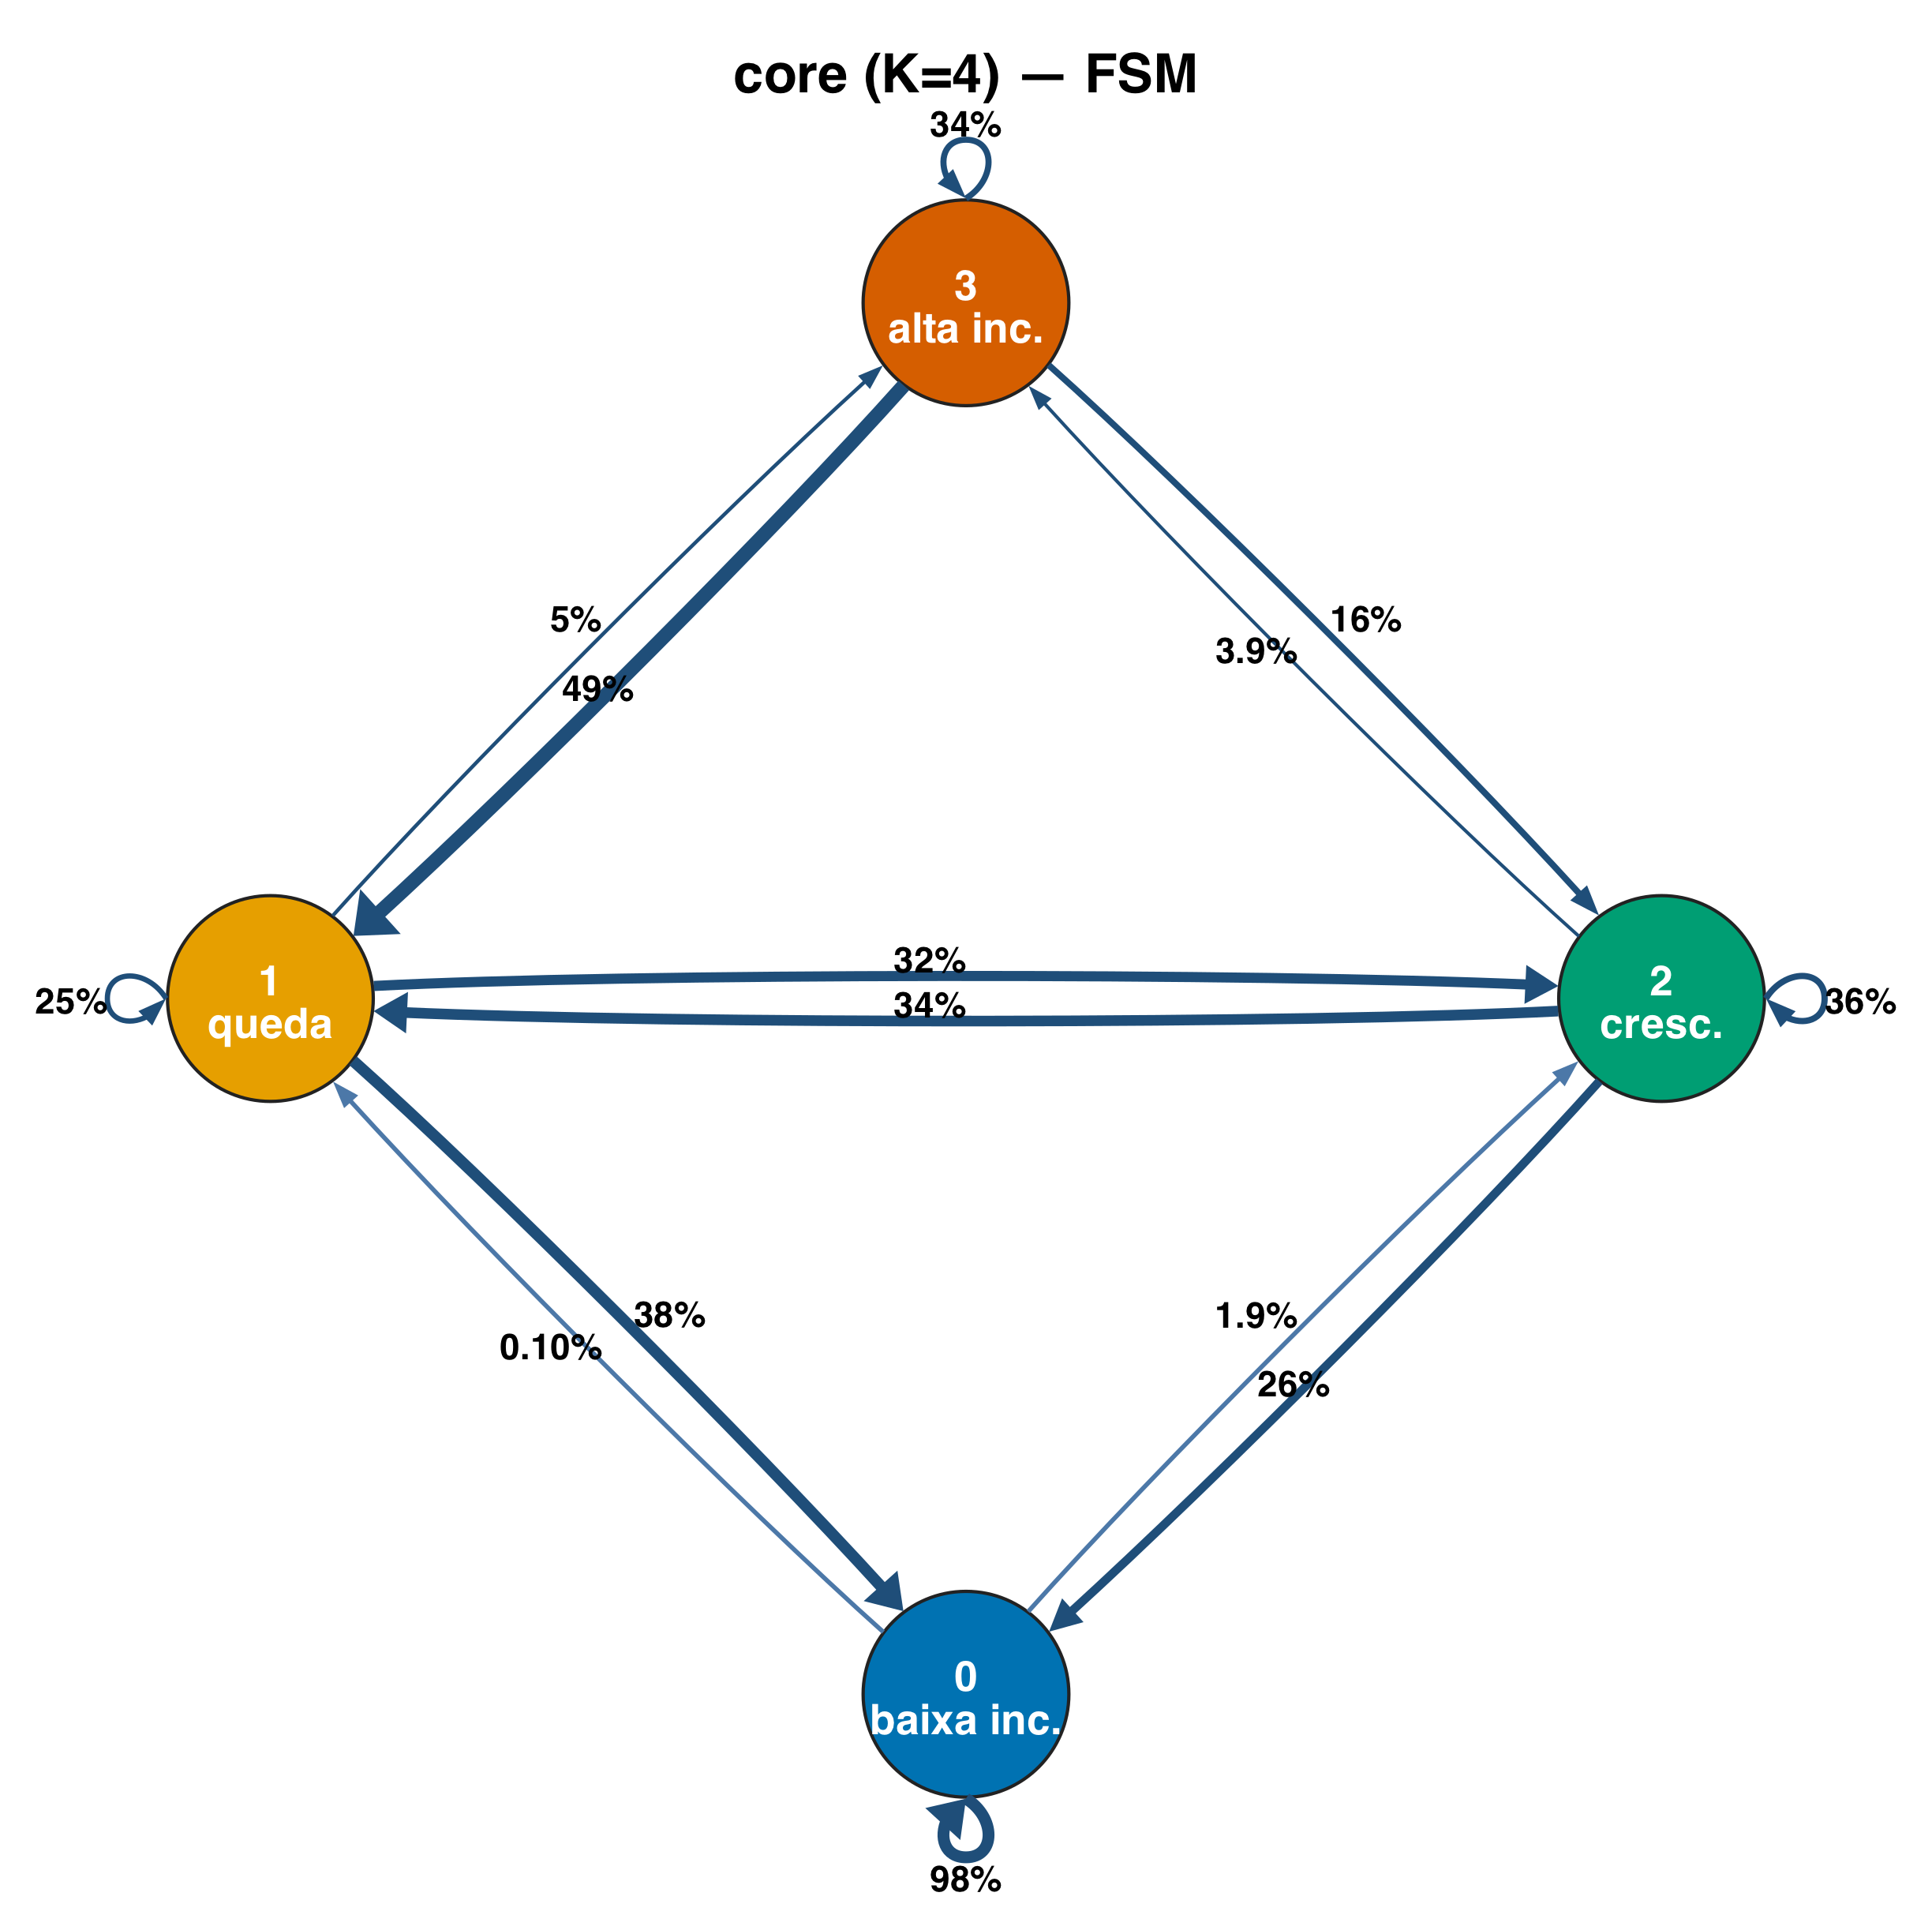

/Users/antonielmagalhaes/d/acad/ia-final/ia-iv/data/cache/fsm_core_graphviz.png


In [46]:
import graphviz
from IPython.display import Image, display

LOOP_PORT = {0: "s", 1: "w", 2: "e", 3: "n"}  # sul / oeste / leste / norte


def _fmt_prob(p: float) -> str:
    if p >= 0.05:
        return f"{p:.0%}"
    if p >= 0.01:
        return f"{p:.1%}"
    return f"{p:.2%}"


def plot_transition_fsm_graphviz(
    trans,
    *,
    state_labels: dict[int, str],
    palette: list[str],
    title: str = "core (K=4) — FSM",
    out_path: Path | None = None,
    display_width: int = 1200,
) -> Path:
    """FSM Graphviz em alta resolução, texto grande, pouco padding."""
    g = graphviz.Digraph("fsm_core", format="png", engine="circo")
    g.attr(
        size="8,8!",
        dpi="300",
        pad="0.15",
        margin="0.08",
        bgcolor="white",
        overlap="false",
        splines="true",
        sep="+18,18",
        nodesep="0.55",
        mindist="1.15",
        label=title,
        labelloc="t",
        fontsize="36",
        fontname="Helvetica-Bold",
    )
    g.attr(
        "node",
        shape="circle",
        style="filled",
        fontname="Helvetica-Bold",
        fontsize="28",
        fontcolor="white",
        width="1.9",
        height="1.9",
        fixedsize="true",
        penwidth="2.2",
    )
    g.attr(
        "edge",
        fontname="Helvetica-Bold",
        fontsize="24",
        color="#1f4e79",
        labelfontcolor="#111111",
        arrowsize="1.2",
        penwidth="2.0",
    )

    n = len(trans)
    for i in range(n):
        short = (
            str(state_labels.get(i, i))
            .replace("crescimento", "cresc.")
            .replace("incidência", "inc.")
            .replace("transição: ", "")
        )
        g.node(
            str(i),
            label=f"{i}\\n{short}",
            fillcolor=palette[i % len(palette)],
            color="#222222",
        )

    for i in range(n):
        p = float(trans.fillna(0).loc[i, i]) if i in trans.index and i in trans.columns else 0.0
        if p <= 0:
            continue
        port = LOOP_PORT.get(i, "e")
        g.edge(
            f"{i}:{port}",
            f"{i}:{port}",
            label=_fmt_prob(p),
            penwidth=str(2.0 + 6.0 * p),
            color="#1f4e79",
            fontsize="24",
            fontname="Helvetica-Bold",
        )

    for src in range(n):
        for dst in range(n):
            if src == dst:
                continue
            if src not in trans.index or dst not in trans.columns:
                continue
            p = float(trans.fillna(0).loc[src, dst])
            if p <= 0:
                continue
            if src == 0 and p < 0.05:
                pw, color = 3.0, "#4C78A8"
            else:
                pw, color = 1.6 + 8.0 * min(p / 0.5, 1.0), "#1f4e79"
            g.edge(
                str(src),
                str(dst),
                label=_fmt_prob(p),
                penwidth=str(pw),
                color=color,
                fontsize="24",
                fontname="Helvetica-Bold",
            )

    out = out_path or (ROOT / "data" / "cache" / "fsm_core_graphviz")
    out.parent.mkdir(parents=True, exist_ok=True)
    rendered = Path(g.render(str(out), cleanup=True))
    return rendered


labels_core = {i: NOMES[i] for i in range(K_FINAL)}
fsm_png = plot_transition_fsm_graphviz(
    trans_core_ord,
    state_labels=labels_core,
    palette=PALETTE[:K_FINAL],
    title=f"core (K={K_FINAL}) — FSM",
    display_width=1200,
)
# width alto no notebook para o texto ficar legível na tela
display(Image(filename=str(fsm_png), width=1200))
print(fsm_png)



### 7.1 Checagem de utilidade (não é treino supervisionado)

Pergunta posterior: semanas no cluster de **crescimento** migram mais para clusters de **maior incidência** na semana seguinte do que semanas no cluster de baixa incidência?

Isso não treina o modelo. Só verifica se o perfil dinâmico tem leitura útil.

In [47]:
# IDs narrativos fixos (após remapeamento da seção 6)
cluster_baixo = 0
cluster_queda = 1
cluster_cresc = 2
cluster_alto = 3

print(f"0 = {NOMES[0]} | 1 = {NOMES[1]} | 2 = {NOMES[2]} | 3 = {NOMES[3]}")

# pares t -> t+1
df = panel_final[[Col.ID_MUNICIP, Col.SEM_NOT]].copy()
df["cluster"] = res_final.labels
df = df.sort_values([Col.ID_MUNICIP, Col.SEM_NOT])
df["cluster_next"] = df.groupby(Col.ID_MUNICIP)["cluster"].shift(-1)
df["inc_next"] = panel_final.assign(cluster=res_final.labels).sort_values(
    [Col.ID_MUNICIP, Col.SEM_NOT]
)[Feat.INCIDENCIA_100K].groupby(
    panel_final.sort_values([Col.ID_MUNICIP, Col.SEM_NOT])[Col.ID_MUNICIP]
).shift(-1).values

pairs = df.dropna(subset=["cluster_next"]).copy()
pairs["cluster_next"] = pairs["cluster_next"].astype(int)

def p_to_high(src: int) -> float:
    sub = pairs[pairs["cluster"] == src]
    if len(sub) == 0:
        return float("nan")
    return float((sub["cluster_next"] == cluster_alto).mean())

def med_inc_next(src: int) -> float:
    sub = pairs[pairs["cluster"] == src]
    return float(sub["inc_next"].median()) if len(sub) else float("nan")

util = pd.DataFrame([
    {
        "origem": src,
        "leitura": NOMES[src],
        "n_transições": int((pairs["cluster"] == src).sum()),
        "P(ir para alta)": p_to_high(src),
        "mediana incidência t+1": med_inc_next(src),
    }
    for src in range(K_FINAL)
])
display(util.round(3))

print(
    f"Comparação-chave: P(alta | crescimento)={p_to_high(cluster_cresc):.3f} "
    f"vs P(alta | baixa)={p_to_high(cluster_baixo):.3f}"
)


0 = baixa incidência | 1 = transição: queda | 2 = transição: crescimento | 3 = alta incidência


,origem,leitura,n_transições,P(ir para alta),mediana incidência t+1
0,0,baixa incidência,16724,0.000,0.000
1,1,transição: queda,418,0.053,217.906
2,2,transição: crescimento,725,0.039,261.165
3,3,alta incidência,85,0.341,927.853


Comparação-chave: P(alta | crescimento)=0.039 vs P(alta | baixa)=0.000


---

## 8. Conclusão

1. **Unidade:** município×semana, não município fixo.
2. **v0** responde volume; silhouette alta não significa relevância epidemiológica.
3. **core** (incidência × crescimento) responde a pergunta útil: mesmo nível, trajetórias diferentes.
4. Clusters são estágios interpretáveis, não definição oficial de surto.
5. A checagem de transição é validação posterior: o perfil de crescimento deve migrar mais para alta incidência do que o perfil de baixa.

**Formulação segura:** ferramenta exploratória para vigilância de trajetórias, não predição de surto.